# Rosario 15 minute city

## Configuración del entorno

Importamos librerías y dependencias.

In [31]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from shapely.validation import explain_validity
from shapely.ops import unary_union

Configuración de visualización.

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (10, 8)

Configuración de rutas.

In [ ]:
RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = RAW_DIR / "lugares_datos_utiles.geojson"

## Descarga de datos

Descargar el dataset inicial desde el servicio web integral de lugares y datos útiles de la Municipalidad de Rosario: https://datosabiertos.rosario.gob.ar/dataset/cd987077-362c-44c9-bda1-043e2e4d505d

In [4]:
url = "http://ws.rosario.gov.ar/ubicaciones/public/geojson/lugaresDatosUtiles/all/true/0/all"

response = requests.get(url, timeout=60)

# Lanza una excepción si la API devuelve un error HTTP
response.raise_for_status()

print(f"Status: {response.status_code}")
print(f"Content-Type: {response.headers.get('Content-Type')}")
print(f"Tamaño de la respuesta: {len(response.content):,} bytes")

Status: 200
Content-Type: application/json
Tamaño de la respuesta: 1,940,270 bytes


In [11]:
with open(RAW_FILE, "wb") as f:
    f.write(response.content)

print(f"Archivo guardado en: {RAW_FILE.resolve()}")

Archivo guardado en: D:\Documentos\MaxucaS\rosario-15-minute-city\data\raw\lugares_datos_utiles.geojson


## Exploración inicial

### Cargar GeoJSON

Cargar la instancia en GeoPandas con el crs original.

In [ ]:
gdf = gpd.GeoDataFrame.from_features(response.json()["features"], crs="EPSG:22185")

Veamos las primeras filas:

In [13]:
display(gdf.head())

,geometry,calculo_coord_ref,descripcion,piso,estado,calle,direccion,codigo_calle,divs_admin,letra,tipo_geometria,bis,ultima_actualizacion,multimedia,altura,etiquetas,name,depto,subtipo,contactos,atencion,id,coordenada_ref,lineas_tup,titular,codigo_interseccion,interseccion
0,POINT (5432148.769 6361708.566),geometria,,,Publicado,1332,1332 3177,5150.0,"[{'codigo': '1', 'nombreAbrev': 'NORTE', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'valo...",NaN,Punto,False,23/09/2019 10:50,[],3177.0,"[{'id': 77, 'nombre': 'Datos útiles'}]",Centro de Recepción de Residuos Reciclables,,LUGAR,[],,5914,"[5432148.768664516, 6361708.56602769]","[102 Roja, 107 Negra, 107 Roja, 153 Negra]",Municipal,NaN,NaN
1,POINT (5435654.73 6362296.91),geometria,,,Publicado,CARRASCO EUDORO,CARRASCO EUDORO 3650,36600.0,"[{'codigo': '1', 'nombreAbrev': 'NORTE', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'valo...",NaN,Punto,False,03/10/2017 10:09,[],3650.0,"[{'id': 77, 'nombre': 'Datos útiles'}]","Embarcadero ""Costa Alta""",,LUGAR,"[{'tipo': 'Teléfono', 'descripcion': '154021019 / 156777823'}]",,1687,"[5435654.73, 6362296.91]",[153 Negra],Privado,NaN,NaN
2,POINT (5439390.382 6352349.182),geometria,,,Publicado,CORRIENTES,CORRIENTES 2879,43250.0,"[{'codigo': '3', 'nombreAbrev': 'CENTRO', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'val...",NaN,Punto,False,31/07/2018 09:58,[],2879.0,"[{'id': 77, 'nombre': 'Datos útiles'}]",Dirección Provincial de Políticas de Género,,LUGAR,[],,5670,"[5439390.382258602, 6352349.181511768]","[103 Negra, 103 Roja, 107 Negra, 107 Roja, 110, 112 Negra, 112 Roja, 113, 116, 128 Negra, 128 Ro...",Municipal,NaN,NaN
3,POINT (5439562.355 6353331.615),geometria,,,Publicado,CORRIENTES,CORRIENTES 2114,43250.0,"[{'codigo': '3', 'nombreAbrev': 'CENTRO', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'val...",NaN,Punto,False,07/08/2018 09:58,[],2114.0,"[{'id': 77, 'nombre': 'Datos útiles'}]",Centro de Asistencia Judicial,,LUGAR,[],,5669,"[5439562.35510406, 6353331.61534218]","[103 Negra, 103 Roja, 107 Negra, 107 Roja, 116, 128 Negra, 128 Roja, 129, 131, 132, 134, 135, 141]",Municipal,NaN,NaN
4,POINT (5440940.002 6354922.384),geometria,,,Publicado,SANTA FE,SANTA FE 638,86550.0,"[{'codigo': '3', 'nombreAbrev': 'CENTRO', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'val...",NaN,Punto,False,03/01/2022 08:25,[],638.0,"[{'id': 77, 'nombre': 'Datos útiles'}]",Centro de Protección Alicia Moreau,,LUGAR,[],,5668,"[5440940.00234185, 6354922.38402761]","[101 Negra, 102 Roja, 106 Ibarlucea, 106 Municipal, 110, 112 Negra, 112 Roja, 116, 121, 122 Roja...",Municipal,NaN,NaN


Y su estructura:

In [14]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   geometry              981 non-null    geometry
 1   calculo_coord_ref     981 non-null    str     
 2   descripcion           981 non-null    str     
 3   piso                  707 non-null    str     
 4   estado                981 non-null    str     
 5   calle                 981 non-null    str     
 6   direccion             981 non-null    str     
 7   codigo_calle          912 non-null    float64 
 8   divs_admin            981 non-null    object  
 9   letra                 3 non-null      str     
 10  tipo_geometria        981 non-null    str     
 11  bis                   981 non-null    bool    
 12  ultima_actualizacion  981 non-null    str     
 13  multimedia            981 non-null    object  
 14  altura                904 non-null    float64 
 15

### Geometrías

In [18]:
display(gdf.geometry.geom_type.value_counts(dropna=False))

Point           897
MultiPolygon     79
Polygon           3
LineString        2
Name: count, dtype: int64

In [ ]:
print("Geometrías nulas:", gdf.geometry.isna().sum())
print("Geometrías vacías:", gdf.geometry.is_empty.sum())
print("Geometrías inválidas:", (~gdf.geometry.is_valid & gdf.geometry.notna()).sum())

Geometrías nulas: 0
Geometrías vacías: 0
Geometrías inválidas: 2


Encontremos cuáles son esas geometrías inválidas y por qué:

In [32]:
# Filtrar el GeoDataFrame
gdf_geometrias_invalidas = gdf[~gdf.geometry.is_valid & gdf.geometry.notna()]
# Usar Shapely para ver exactamente cuál es el error geométrico
for index, row in gdf_geometrias_invalidas.iterrows():
    motivo = explain_validity(row.geometry)
    print(f"ID {row['id']} ({row['name']}): {motivo}")

Reparar geometrías

In [ ]:
gdf['geometry'] = gdf.geometry.make_valid()
print("Geometrías inválidas restantes:", (~gdf.geometry.is_valid & gdf.geometry.notna()).sum())

Geometrías inválidas restantes: 0


In [26]:
display(gdf.geometry.geom_type.value_counts(dropna=False))

Point                 897
MultiPolygon           77
Polygon                 3
LineString              2
GeometryCollection      2
Name: count, dtype: int64

Como podemos observar, se convirtieron en GeometryCollection, para algunas operaciones de análisis espacial este tipo de geometría puede darnos errores por lo que procederemos a limpiarlas extrayendo los polígonos que hayan en cada colección.

In [ ]:
gdf['geometry'] = gdf['geometry'].apply(
    lambda geom: unary_union([g for g in geom.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]) 
    if geom.geom_type == 'GeometryCollection' else geom
)

Tipos de geometría finales:


Point           897
MultiPolygon     79
Polygon           3
LineString        2
Name: count, dtype: int64

In [34]:
display(gdf.geometry.geom_type.value_counts(dropna=False))

Point           897
MultiPolygon     79
Polygon           3
LineString        2
Name: count, dtype: int64

### Etiquetas

In [39]:
display(gdf[['name', 'etiquetas']].head())

,name,etiquetas
0,Centro de Recepción de Residuos Reciclables,"[{'id': 77, 'nombre': 'Datos útiles'}]"
1,"Embarcadero ""Costa Alta""","[{'id': 77, 'nombre': 'Datos útiles'}]"
2,Dirección Provincial de Políticas de Género,"[{'id': 77, 'nombre': 'Datos útiles'}]"
3,Centro de Asistencia Judicial,"[{'id': 77, 'nombre': 'Datos útiles'}]"
4,Centro de Protección Alicia Moreau,"[{'id': 77, 'nombre': 'Datos útiles'}]"


In [30]:
etiquetas = (
    gdf["etiquetas"]
    .dropna()
    .astype(str)
    .str.strip()
)

display(etiquetas.value_counts().head(50))

etiquetas
[{'id': 42, 'nombre': 'Oficina'}, {'id': 77, 'nombre': 'Datos útiles'}]                                                                                                                                                                                                  239
[{'id': 42, 'nombre': 'Oficina'}, {'id': 48, 'nombre': 'Realiza Trámites'}, {'id': 77, 'nombre': 'Datos útiles'}]                                                                                                                                                        178
[{'id': 41, 'nombre': 'Institución'}, {'id': 77, 'nombre': 'Datos útiles'}, {'id': 91, 'nombre': 'Vecinales'}]                                                                                                                                                            88
[{'id': 31, 'nombre': 'Plaza'}, {'id': 77, 'nombre': 'Datos útiles'}, {'id': 78, 'nombre': 'Espacios Verdes'}]                                                                         

In [31]:
etiquetas_individuales = (
    gdf["etiquetas"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

etiquetas_individuales = etiquetas_individuales[
    etiquetas_individuales.ne("")
]

display(etiquetas_individuales.value_counts().head(100))

etiquetas
{'id': 77                     940
'nombre': 'Datos útiles'}]    589
'nombre': 'Oficina'}          449
[{'id': 42                    434
'nombre': 'Datos útiles'}     392
                             ... 
'nombre': 'Patrimonio'}         1
[{'id': 2                       1
'nombre': 'Escuela'}            1
'nombre': 'CMD'}]               1
{'id': 130                      1
Name: count, Length: 100, dtype: int64

In [32]:
for col in ["titular", "divs_admin", "tipo_geometria", "subtipo"]:
    if col in gdf.columns:
        print(f"\n--- {col} ---")
        display(gdf[col].value_counts(dropna=False).head(30))


--- titular ---


titular
Municipal     758
Provincial     96
ONG            85
Privado        30
Nacional        9
Mixto           3
Name: count, dtype: int64


--- divs_admin ---


divs_admin
[{'codigo': '3', 'nombreAbrev': 'CENTRO', 'tipo': 1, 'idTipo': 1, 'nombreTipo': 'Distrito', 'valor': 'CENTRO'}, {'codigo': '67', 'nombreAbrev': 'Monumento a la Bandera', 'tipo': 4, 'idTipo': 10, 'nombreTipo': 'Vecinal', 'valor': 'Monumento a la Bandera'}, {'codigo': '15', 'nombreAbrev': 'CENTRO', 'tipo': 3, 'idTipo': 9, 'nombreTipo': 'Barrio', 'valor': 'CENTRO'}, {'codigo': '3', 'nombreAbrev': 'Comisaría 3', 'tipo': 2, 'idTipo': 2, 'nombreTipo': 'Seccional Policial', 'valor': 'Comisaría 3'}, {'codigo': '54', 'nombreAbrev': '56', 'tipo': 5, 'idTipo': 4, 'nombreTipo': 'Fracción Censal', 'valor': '56'}, {'codigo': '1647', 'nombreAbrev': '2106', 'tipo': 6, 'idTipo': 3, 'nombreTipo': 'Radio Censal', 'valor': '2106'}, {'codigo': '1', 'nombreAbrev': '1A', 'tipo': 7, 'idTipo': 11, 'nombreTipo': 'Zona Notificación', 'valor': '1A'}, {'codigo': '2', 'nombreAbrev': 'Centro', 'tipo': 12, 'idTipo': 12, 'nombreTipo': 'Identidad Barrial', 'valor': 'Centro'}]                                 


--- tipo_geometria ---


tipo_geometria
Punto        897
Multiarea     79
Area           3
Tramo          2
Name: count, dtype: int64


--- subtipo ---


subtipo
LUGAR    981
Name: count, dtype: int64

In [34]:
if "ultima_actualizacion" in gdf.columns:
    fechas = pd.to_datetime(
        gdf["ultima_actualizacion"],
        errors="coerce",
        dayfirst=True
    )

    print("Fechas no interpretadas:", fechas.isna().sum())
    print("Fecha más antigua:", fechas.min())
    print("Fecha más reciente:", fechas.max())

    display(
        fechas.dt.year.value_counts(dropna=False).sort_index()
    )

Fechas no interpretadas: 0
Fecha más antigua: 2017-08-01 09:35:00
Fecha más reciente: 2026-08-27 15:18:00


ultima_actualizacion
2017    307
2018     90
2019    174
2020     35
2021    129
2022     65
2023     44
2024     18
2025     82
2026     37
Name: count, dtype: int64

In [36]:
if "id" in gdf.columns:
    print("IDs duplicados:", gdf["id"].duplicated().sum())

IDs duplicados: 0


In [39]:
columnas_clave = [
    col for col in ["name", "direccion"]
    if col in gdf.columns
]

if columnas_clave:
    duplicados = gdf.duplicated(
        subset=columnas_clave,
        keep=False
    )

    print("Posibles duplicados por nombre/dirección:", int(duplicados.sum() / 2))

    display(
        gdf.loc[duplicados, columnas_clave]
        .sort_values(columnas_clave)
        .head(50)
    )

Posibles duplicados por nombre/dirección: 4


,name,direccion
85,Administración Provincial de Impuestos (API),TUCUMAN 1853
520,Administración Provincial de Impuestos (API),TUCUMAN 1853
864,"Centro Municipal de Distrito Noroeste ""Olga y ...",PROVINCIAS UNIDAS 150 BIS
926,"Centro Municipal de Distrito Noroeste ""Olga y ...",PROVINCIAS UNIDAS 150 BIS
247,Plataforma Lavardén,MENDOZA 1085
506,Plataforma Lavardén,MENDOZA 1085
327,Servicio Público de la Vivienda y el Hábitat,PARAGUAY 153
591,Servicio Público de la Vivienda y el Hábitat,PARAGUAY 153


In [42]:
print("Bounds:", gdf.total_bounds)

Bounds: [5427644.27       6345899.42       5442573.35722461 6363171.71      ]


In [43]:
minx, miny, maxx, maxy = gdf.total_bounds
print(f"Longitud: {minx:.5f} a {maxx:.5f}")
print(f"Latitud:  {miny:.5f} a {maxy:.5f}")

Longitud: 5427644.27000 a 5442573.35722
Latitud:  6345899.42000 a 6363171.71000


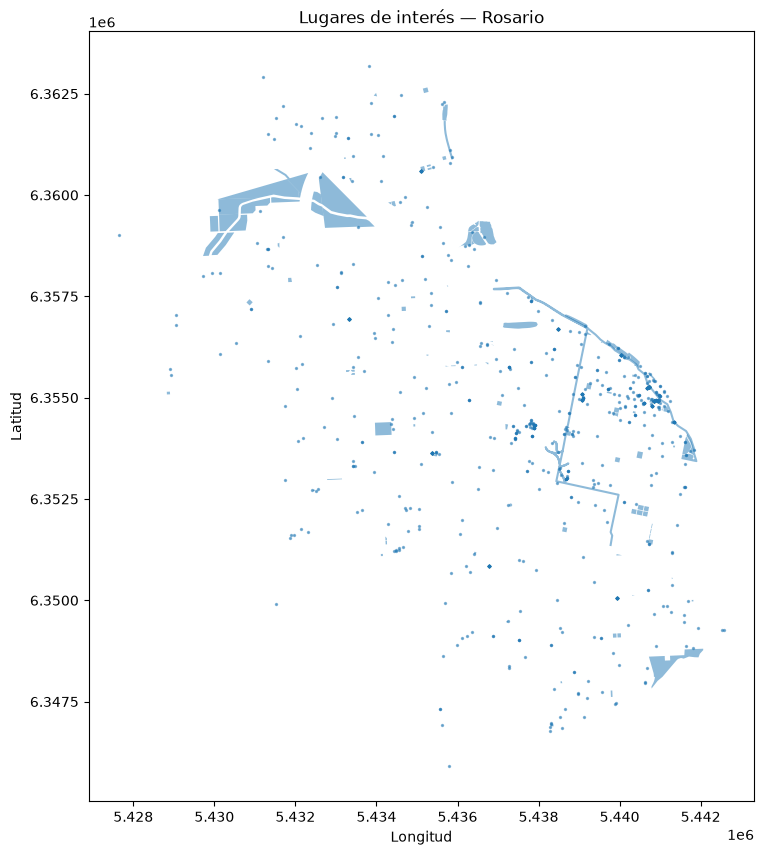

In [51]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=2,
    alpha=0.5,
    aspect=1
)

ax.set_title("Lugares de interés — Rosario")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.show()

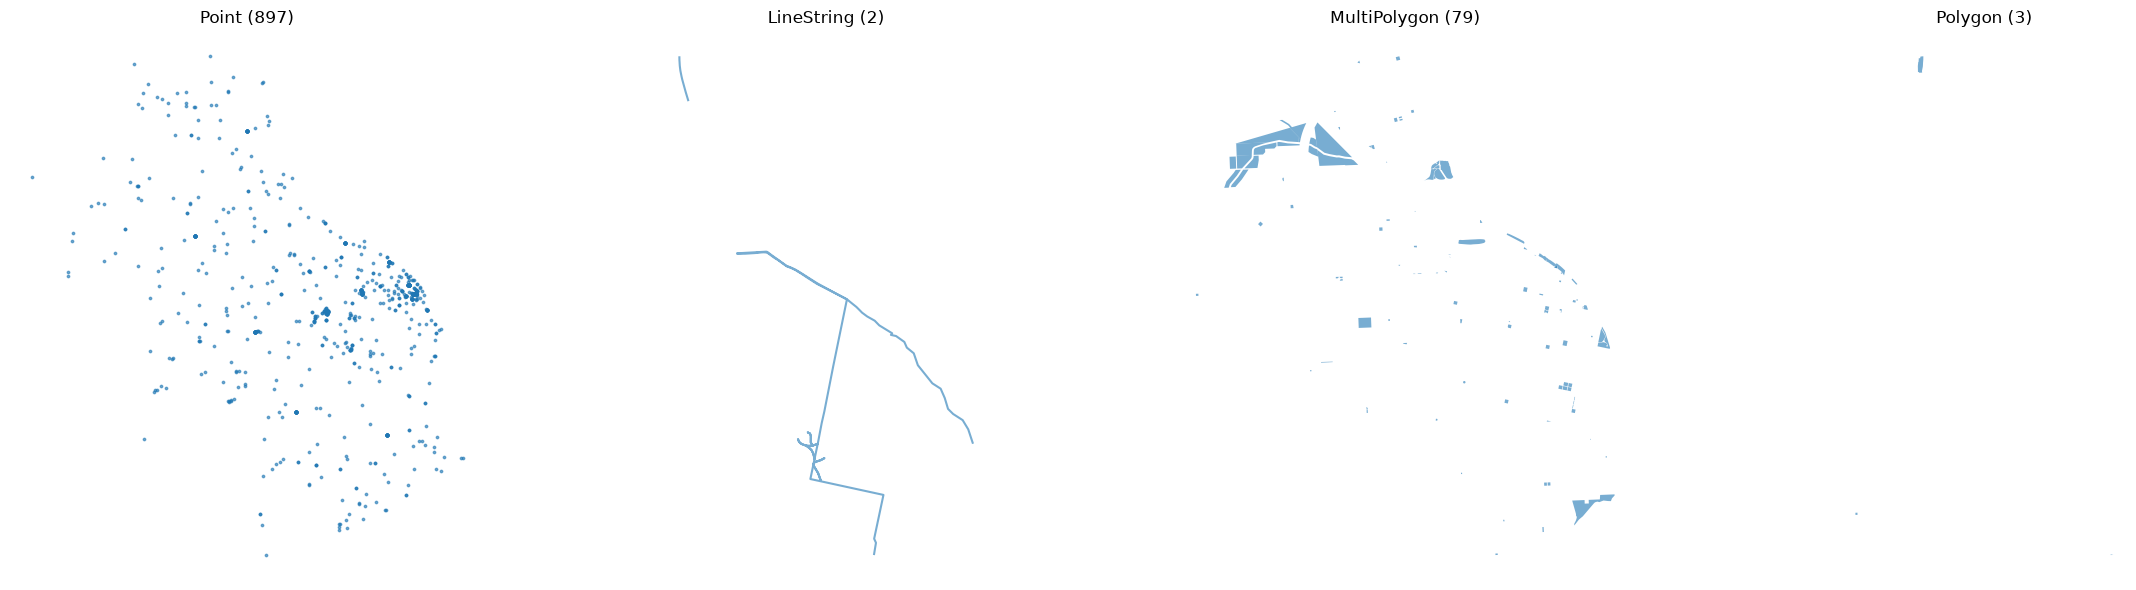

In [52]:
tipos = gdf.geometry.geom_type.dropna().unique()

fig, axes = plt.subplots(
    1,
    len(tipos),
    figsize=(6 * len(tipos), 6)
)

if len(tipos) == 1:
    axes = [axes]

for ax, tipo in zip(axes, tipos):
    subset = gdf[gdf.geometry.geom_type == tipo]

    subset.plot(
        ax=ax,
        markersize=3,
        alpha=0.6,
        aspect=1
    )

    ax.set_title(f"{tipo} ({len(subset):,})")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [53]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_DIR / "lugares.gpkg"

gdf.to_file(
    OUTPUT_FILE,
    layer="lugares",
    driver="GPKG"
)

print(f"GeoPackage guardado en: {OUTPUT_FILE.resolve()}")

GeoPackage guardado en: D:\Documentos\MaxucaS\rosario-15-minute-city\data\processed\lugares.gpkg
